In [1]:
import numpy as np
import random
from model_evaluation import *
from sklearn.metrics import roc_curve, auc
from scipy.special import kv #modified bessel function
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import scipy.signal
import scipy.io as scio
np.random.seed(1)
random.seed(1)
from Data.Data_import import data_frame
from model import model_train 
Data = data_frame()
# pilot_train,calm_train,pilot_test,unlabeled_data = model_train.dataset_generate(Data, dim_vr=9)
# calm_test = Data.calm_test_generator()
# idx = np.arange(5-9//2,6+9//2,1)
# calm_test = calm_test[...,idx]
# scio.savemat('Data_for_test.mat',{'pilot_train':pilot_train,'calm_train':calm_train,
# 'pilot_test':pilot_test,'calm_test':calm_test,
# 'hazard_position_train':Data.hazard_position_train,
# 'hazard_position_test':Data.hazard_position_test,
# 'pilot_ws_mags_test':Data.pilot_ws_mags_test,
# 'pilot_turb_mags_test':Data.pilot_turb_mags_test,
# 'pilot_ws_mag_train':Data.pilot_ws_mag_train,
# 'pilot_turb_mag_train':Data.pilot_turb_mag_train,
# 'pilot_weak':Data.pilot_weak,'pilot_strong':Data.pilot_strong,
# 'other_airports_v_r':Data.other_airports_v_r,
# 'pilot_train_time':Data.pilot_train_time,
# 'pilot_test_time':Data.pilot_test_time
# })
# Data = scio.loadmat('Data_for_test.mat')

d:\Programfiles\Anaconda\envs\tf_new\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
d:\Programfiles\Anaconda\envs\tf_new\lib\site-packages\numpy\.libs\libopenblas.GK7GX5KEQ4F6UYO3P26ULGBQYHGQO7J4.gfortran-win_amd64.dll
d:\Programfiles\Anaconda\envs\tf_new\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"
d:\Programfiles\Anaconda\envs\tf_new\lib\site-packages\tensorflow\python\client\session.py:1769: UserWarning: An interactive session is already active. This can cause out-of-memory errors in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s).
  warnings.warn('An interactive session is already active. This can '


In [ ]:
calm_test = Data.calm_test_generator()
calm_train = Data.calm_train
scio.savemat('calm_data.mat',{'calm_test':calm_test,'calm_train':calm_train})

In [4]:
# pilot_train=Data['pilot_train']
pilot_train,calm_train,pilot_test,unlabeled_data = model_train.dataset_generate(Data, dim_vr=11)
for i in [2]:#range(pilot_train.shape[0]):
    plt.figure(figsize=(10,4))
    ax_left = plt.subplot2grid((3, 2), (0, 1), rowspan=3)
    plt.pcolormesh(pilot_train[i].T,cmap='Spectral_r')
    plt.colorbar()
    plt.xticks([])
    plt.grid(True, color='black', linewidth=0.5, linestyle='--')  # 显示网格线
    ax_right_top = plt.subplot2grid((3, 2), (0, 0))
    ax_right_top.plot(pilot_train[i][...,-1])
    ax_right_top.set_title('Top')

    ax_right_mid = plt.subplot2grid((3, 2), (1, 0), sharey=ax_right_top)
    ax_right_mid.plot(pilot_train[i][...,4])
    ax_right_mid.set_title('Middle')

    ax_right_bottom = plt.subplot2grid((3, 2), (2, 0), sharey=ax_right_top)
    ax_right_bottom.plot(pilot_train[i][...,0])
    ax_right_bottom.set_title('Bottom')

    plt.tight_layout()
    
    plt.savefig(f'E:\Work_in_2026\papers\\attention_guide\paper_related\\data_illustration.pdf')
    plt.close()

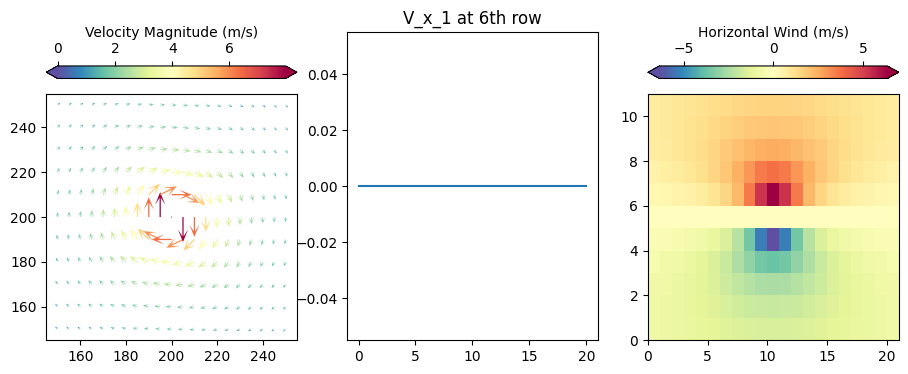

In [32]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(11,4))
# 创建网格
X, Y = np.meshgrid(np.arange(150, 251, 5), np.arange(150, 251, 10))

O_L = [200, 200]
r_c = 5  # 涡心半径
Gamma = 500  # 环量

# 计算距离
r_L = np.sqrt((Y - O_L[1])**2 + (X - O_L[0])**2) + 1e-8

# 计算速度场
V_1_alpha = Gamma / (2 * np.pi * (r_L**2 + r_c**2))

# 计算速度分量
V_x_1 = V_1_alpha * (Y - O_L[1])
V_y_1 = -V_1_alpha * (X - O_L[0])

# 绘制矢量图
plt.subplot(131)
speed = np.hypot(V_x_1, V_y_1)
q = plt.quiver(
    X, Y,  # 降低箭头密度
    V_x_1, V_y_1,  # 速度分量
    speed,  # 颜色映射值
    cmap='Spectral_r',
    scale=80,  # 调整箭头大小
    width=0.005,  # 箭头宽度
    headwidth=8,  # 箭头头部宽度
    headlength=10  # 箭头头部长度
)

# 添加颜色条
cbar = plt.colorbar(q, label='Velocity Magnitude (m/s)',location='top',extend='both')
cbar.ax.tick_params(labelsize=10)


# 绘制第6行的V_x_1
plt.subplot(132)
plt.plot(V_x_1[5, :])  # Python是0-based索引，所以第6行对应索引5
plt.title('V_x_1 at 6th row')


# 绘制伪彩色图
plt.subplot(133)
plt.pcolormesh(V_x_1,cmap='Spectral_r')
plt.colorbar(label='Horizontal Wind (m/s)',location='top',extend='both')
# plt.title('V_x_1 Pseudocolor Plot')
# plt.show()
plt.savefig(f'./paper_related/multi_v_explain.png')
plt.savefig(f'./paper_related/multi_v_explain.pdf')

In [17]:
pilot_train = Data['pilot_train']
percent = 90
window_size = 10
v_data = pilot_train[...,4]
ti_series,fi_series = model_train.calculate_turbulence_intensity(v_data,window_size)
ti_90 = (np.percentile(ti_series,percent,axis=1)).reshape(-1,1)
fi_90 = (np.percentile(fi_series,percent,axis=1)).reshape(-1,1)
attn_phy_mask = np.zeros_like(v_data)
attn_phy_mask[ti_series-ti_90>0]=1
attn_phy_mask[fi_series-fi_90>0]=1

In [21]:
for i in [2,4]:
    plt.figure(figsize=(5,10))
    pilot_report = Data['hazard_position_train']
    
    plt.subplot(411)
    plt.title(Data['pilot_train_time'][i])
    plt.plot(v_data[i,::])
    plt.vlines(np.where(pilot_report[i,::]==1)[0][0],np.min(v_data[i,::]),np.max(v_data[i,::]),colors='g')
    plt.subplot(412)
    plt.plot(fi_series[i,::])
    pos = np.zeros([128,1])
    pos[(fi_series-fi_90)[i,::]>0] = np.max(fi_series[i,::])
    plt.plot()
    plt.plot(pos)
    # plt.vlines(np.where(pilot_report[i,::]==1)[0][0],0,np.max(ti_series[i,::]),colors='g')
    plt.subplot(413)
    plt.plot(ti_series[i,::])
    pos = np.zeros([128,1])
    pos[(ti_series-ti_90)[i,::]>0] = np.max(ti_series[i,::])
    plt.plot(pos)
    plt.subplot(414)
    attn_phy_mask = model_train.cal_t_f(v_data,percent,window_size)
    attn_phy_top = model_train.attn_pos_set(attn_phy_mask,pilot_report)
    plt.plot(attn_phy_mask[i,::])
    # plt.bar([0,1,2,3],attn_phy_top[i,::],1)
    plt.savefig(f'./article/{i}.pdf')
    plt.close()

In [63]:
Data.pilot_train_time[i]

'20170310_0901'

d:\Programfiles\Anaconda\envs\tf_new\lib\site-packages\tensorflow\python\client\session.py:1769: UserWarning: An interactive session is already active. This can cause out-of-memory errors in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s).
  warnings.warn('An interactive session is already active. This can '


INFO:tensorflow:Restoring parameters from sdec_ckpt\model_supervise_attn_pos.ckpt


In [17]:
corridor_v_r_multi_loc3.shape

(11, 128)

C:\Users\gigabyte\AppData\Local\Temp\ipykernel_29300\1997596195.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # 为colorbar留出空间


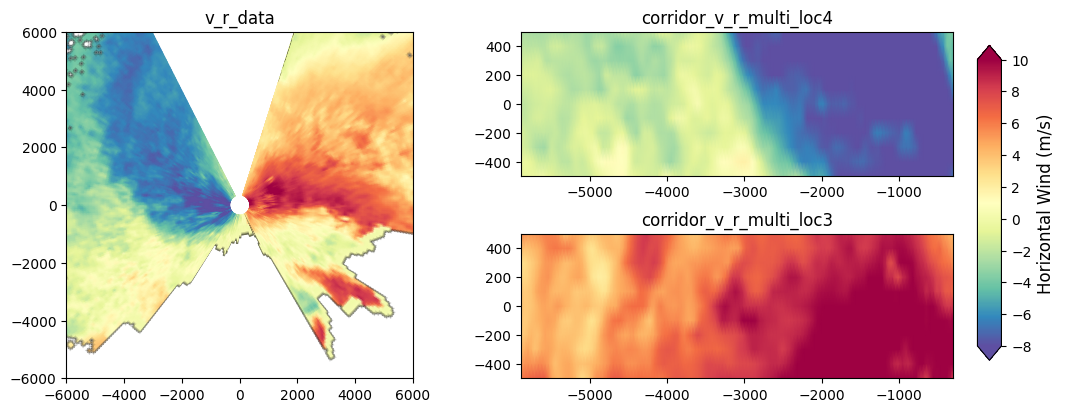

In [31]:
from matplotlib import gridspec

# 创建图形和网格布局
fig = plt.figure(figsize=(12, 4.5))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1], wspace=0.15, hspace=0.4)
vmin = -8
vmax = 10
# 左上图: v_r_data - 占据左侧整个高度
ax1 = plt.subplot(gs[0:2, 0])
im1 = ax1.pcolormesh(pol_x, pol_y, v_r_data, cmap='Spectral_r', shading='gouraud', vmin=vmin, vmax=vmax)
ax1.set_xlim([-6000, 6000])
ax1.set_ylim([-6000, 6000])
ax1.set_title('v_r_data')
ax1.set_aspect('equal')  # 保持纵横比
# cbar1 = fig.colorbar(im1, ax=ax1, location='top', extend='both')
# cbar1.set_label('Horizontal Wind (m/s)')

# 右上图: corridor_v_r_multi_loc4
ax2 = plt.subplot(gs[0, 1])
X, Y = np.meshgrid(x, multi_ys, indexing='ij')
im2 = ax2.pcolormesh(X, Y, corridor_v_r_multi_loc4.T, cmap='Spectral_r', shading='gouraud', vmin=vmin, vmax=vmax)
ax2.set_title('corridor_v_r_multi_loc4')
im2.set_clim(-6, 8)
# cbar2 = fig.colorbar(im2, ax=ax2, location='top', extend='both')
# cbar2.set_label('Horizontal Wind (m/s)')

# 右下图: corridor_v_r_multi_loc3
ax3 = plt.subplot(gs[1, 1])
im3 = ax3.pcolormesh(X, Y, corridor_v_r_multi_loc3.T, cmap='Spectral_r', shading='gouraud', vmin=vmin, vmax=vmax)
ax3.set_title('corridor_v_r_multi_loc3')
im3.set_clim(-6, 8)
# cbar3 = fig.colorbar(im3, ax=ax3, location='top', extend='both')
# cbar3.set_label('Horizontal Wind (m/s)')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cbar_ax, extend='both')
cbar.set_label('Horizontal Wind (m/s)', fontsize=12)

# 调整布局
plt.tight_layout(rect=[0, 0, 0.9, 1])  # 为colorbar留出空间

# 显示图形
plt.savefig(f'./paper_related/data_generate.png')
plt.savefig(f'./paper_related/data_generate.pdf')